# Precificação Dinâmica com Redes Neurais

**1. Contexto de negócio**

Imagine um e-commerce (ou uma companhia aérea) que precisa decidir, todos os dias, **qual preço praticar** para cada produto ou passagem. O objetivo não é vender pelo maior preço possível nem pelo menor: é encontrar o preço que **maximiza a receita esperada**, dado que a demanda dos clientes muda de acordo com:

- o preço praticado em relação ao **preço do concorrente**;
- o **estoque restante** (percepção de escassez);
- a **proximidade da data do evento** (voo, promoção, lançamento);
- o **dia da semana**.

Esse problema é conhecido como **precificação dinâmica** (*dynamic pricing*): usar dados históricos para estimar a curva de demanda em função do preço e do contexto, e então escolher o preço que maximiza `receita = preço × demanda_prevista`.

Neste notebook vamos:
1. Simular um histórico de vendas com uma demanda **não linear** e com **interações** entre preço, estoque e contexto;
2. Treinar dois modelos que preveem a demanda: uma **regressão linear** (baseline) e uma **rede neural** (MLP);
3. Comparar o erro de previsão dos dois modelos;
4. Usar cada modelo para testar uma **grade de preços candidatos** em um cenário fixo e escolher o preço que maximizaria a receita segundo cada abordagem;
5. Comparar essa escolha com a receita **realmente ótima**, que conhecemos porque nós mesmos geramos os dados.

**Limitações deste notebook**

Antes de seguir, vale deixar claro o que este exemplo **não** resolve:

- A função `demanda_verdadeira` que gera os dados é 100% **simulada e conhecida por nós** — inclusive é usada mais adiante como "oráculo" para calcular o preço realmente ótimo e comparar com o que cada modelo escolheria. Em produção, a relação real entre preço e demanda é **desconhecida**, ruidosa, e muda com o tempo (concorrência, sazonalidade, percepção de marca), então não existe esse "gabarito" para validar a decisão de preço.
- Precificação dinâmica em produção também precisa respeitar **restrições de negócio** que não aparecem neste exemplo simplificado: preço mínimo e máximo, percepção de justiça do cliente (evitar variações bruscas ou discriminação de preço perceptível) e, em alguns setores, regulação específica sobre como e quando o preço pode variar.
- Mais adiante repetimos o pipeline com três seeds diferentes (`42`, `7`, `123`) para checar se a vantagem do MLP sobre a regressão linear é robusta — e ela se confirma, de forma grande e consistente nas três. Mas isso reflete a **estrutura não linear que nós escolhemos** para desenhar a demanda simulada (decaimento exponencial, rampa logística, interações multiplicativas). Não é uma garantia de que toda relação real de preço-demanda tenha essa mesma estrutura, nem de que uma rede neural vencerá sempre uma regressão linear em outros contextos.

**2. Por que uma rede neural pode ajudar aqui?**

A demanda real de um produto raramente é uma função linear do preço. Alguns efeitos típicos são:

- a sensibilidade ao preço **não é constante**: pequenas variações de preço perto do preço do concorrente importam muito mais do que variações longe dele;
- o efeito da **proximidade do evento** e do **estoque** não é aditivo — eles **interagem** com o preço (por exemplo, perto da data do evento a demanda fica menos sensível ao preço);
- efeitos de saturação e limiares (ex.: abaixo de um certo estoque a demanda observada cai de forma abrupta) são naturalmente **não lineares**.

Uma regressão linear só consegue capturar efeitos aditivos e proporcionais entre as variáveis originais. Uma rede neural (MLP), por ter camadas ocultas com funções de ativação não lineares, consegue aproximar essas interações e curvas sem que precisemos especificá-las manualmente (por exemplo, sem criar features de interação à mão).

**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /Users/marcofidos/fgv-aulas-env/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

**3. Geração do dataset simulado**

Vamos simular `N` observações de "testes de preço" (por exemplo, o mesmo produto foi oferecido em dias diferentes, com preços diferentes, em contextos diferentes) com as seguintes features:

- `dia_da_semana`: inteiro de 0 (segunda) a 6 (domingo);
- `dias_ate_evento`: quantos dias faltam até a data do evento/voo (1 a 60);
- `estoque_restante`: unidades restantes em estoque (0 a 500);
- `preco_concorrente`: preço praticado pelo concorrente (R$ 60 a R$ 140);
- `preco_praticado`: o preço que foi testado naquela observação (R$ 50 a R$ 150).

A variável alvo é `demanda`: quantas unidades foram vendidas naquele contexto. Ela é gerada por uma função **não linear e multiplicativa** dos fatores acima (mais ruído aleatório), que representa o "processo real" de mercado — desconhecido, na prática, por quem for construir os modelos.

In [3]:
def demanda_verdadeira(dia_da_semana, dias_ate_evento, estoque_restante, preco_concorrente, preco_praticado):
    '''Função geradora da demanda "real" (sem ruído). Não linear e com interações
    multiplicativas entre preço, estoque, proximidade do evento e dia da semana.'''
    base = 100.0

    # sensibilidade ao preço em relação ao concorrente: decaimento exponencial
    razao_preco = preco_praticado / preco_concorrente
    efeito_preco = np.exp(-3.0 * (razao_preco - 1.0))

    # efeito de estoque: rampa logística -- estoque muito baixo reduz bastante a
    # demanda observada (produto quase esgotado / menos exposição), estoque alto
    # satura o efeito em 1.0. Não é linear nem simétrico.
    efeito_estoque = 1.0 / (1.0 + np.exp(-(estoque_restante - 60.0) / 25.0))

    # proximidade do evento: urgência cresce de forma exponencial quando faltam
    # poucos dias
    efeito_proximidade = 1.0 + 0.6 * np.exp(-dias_ate_evento / 10.0)

    # efeito de fim de semana (sábado=5, domingo=6): leve aumento de demanda
    efeito_fds = 1.0 + 0.12 * np.asarray(dia_da_semana >= 5, dtype=float)

    demanda = base * efeito_preco * efeito_estoque * efeito_proximidade * efeito_fds
    return demanda


N = 4000

dia_da_semana = np.random.randint(0, 7, size=N)
dias_ate_evento = np.random.uniform(1, 60, size=N)
estoque_restante = np.random.uniform(0, 500, size=N)
preco_concorrente = np.random.uniform(60, 140, size=N)
preco_praticado = np.random.uniform(50, 150, size=N)

demanda_media = demanda_verdadeira(
    dia_da_semana, dias_ate_evento, estoque_restante, preco_concorrente, preco_praticado
)
ruido = np.random.normal(0, 5.0, size=N)
demanda = np.clip(demanda_media + ruido, 0, None)

df = pd.DataFrame({
    "dia_da_semana": dia_da_semana,
    "dias_ate_evento": dias_ate_evento,
    "estoque_restante": estoque_restante,
    "preco_concorrente": preco_concorrente,
    "preco_praticado": preco_praticado,
    "demanda": demanda,
})

df.head()

,dia_da_semana,dias_ate_evento,estoque_restante,preco_concorrente,preco_praticado,demanda
0,6,59.047,310.968,63.885,103.833,11.832
1,3,16.869,303.396,108.298,124.263,75.405
2,4,25.011,424.735,124.033,74.730,345.911
3,6,53.597,270.602,106.799,73.152,283.298
4,2,1.172,401.930,139.762,144.992,136.131


**4. Separação em treino e teste**

Separamos 80% das observações para treino e 20% para teste. As features usadas por ambos os modelos são exatamente as mesmas — a diferença estará apenas na capacidade de cada modelo capturar as não linearidades e interações.

In [4]:
features = ["dia_da_semana", "dias_ate_evento", "estoque_restante", "preco_concorrente", "preco_praticado"]
alvo = "demanda"

X = df[features].values
y = df[alvo].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} exemplos | Teste: {X_test.shape[0]} exemplos")

Treino: 3200 exemplos | Teste: 800 exemplos


**5. Modelo baseline: Regressão Linear**

Usamos uma `LinearRegression` (com padronização das features via `StandardScaler`) para prever a demanda a partir das cinco features. Esse modelo só consegue capturar uma relação **aditiva e linear** entre cada feature e a demanda.

In [5]:
modelo_lr = make_pipeline(StandardScaler(), LinearRegression())
modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print(f"Regressão Linear -> MAE: {mae_lr:.3f} | RMSE: {rmse_lr:.3f}")

Regressão Linear -> MAE: 54.265 | RMSE: 74.897


**6. Modelo de rede neural: MLPRegressor**

Agora treinamos um `MLPRegressor` (perceptron multicamadas) com duas camadas ocultas, usando as mesmas features (também padronizadas). A rede neural pode aprender combinações não lineares entre preço, estoque, proximidade do evento e dia da semana sem que precisemos criar manualmente essas interações.

In [6]:
modelo_mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        max_iter=3000,
        early_stopping=True,
        random_state=42,
    ),
)
modelo_mlp.fit(X_train, y_train)

pred_mlp = modelo_mlp.predict(X_test)
mae_mlp = mean_absolute_error(y_test, pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))

print(f"MLP (rede neural) -> MAE: {mae_mlp:.3f} | RMSE: {rmse_mlp:.3f}")

MLP (rede neural) -> MAE: 11.761 | RMSE: 18.247


**7. Comparação do erro de previsão**

A tabela abaixo resume o erro de previsão de demanda (em unidades vendidas) de cada modelo no conjunto de teste. Quanto menor o MAE/RMSE, melhor o modelo consegue prever a demanda real.

In [7]:
comparacao_erro = pd.DataFrame({
    "Modelo": ["Regressão Linear", "MLP (rede neural)"],
    "MAE (unidades)": [mae_lr, mae_mlp],
    "RMSE (unidades)": [rmse_lr, rmse_mlp],
})
comparacao_erro

,Modelo,MAE (unidades),RMSE (unidades)
0,Regressão Linear,54.265,74.897
1,MLP (rede neural),11.761,18.247


**8. Demonstração de valor: escolhendo o preço com cada modelo**

Agora vem a parte que interessa ao negócio: dado um **cenário fixo** (um contexto de venda específico), qual preço cada modelo recomendaria?

Cenário de exemplo:
- fim de semana (`dia_da_semana = 5`, sábado);
- evento próximo (`dias_ate_evento = 5`);
- estoque moderado (`estoque_restante = 100`);
- concorrente cobrando `preco_concorrente = 90`.

Vamos testar uma grade de preços candidatos de R\$ 50 a R\$ 150 e, para cada preço, calcular a **receita esperada = preço × demanda prevista** segundo cada modelo. O preço escolhido por cada abordagem é aquele que maximiza essa receita esperada.

Como nós mesmos simulamos os dados, também sabemos a **função geradora verdadeira** da demanda — isso nos permite calcular a receita **realmente** obtida se o preço escolhido por cada modelo fosse praticado, e comparar com o preço/receita verdadeiramente ótimos (o "oráculo").

In [8]:
precos_candidatos = np.linspace(50, 150, 101)

dia_cenario = 5
dias_evento_cenario = 5
estoque_cenario = 100.0
preco_concorrente_cenario = 90.0

grade = pd.DataFrame({
    "dia_da_semana": np.full_like(precos_candidatos, dia_cenario),
    "dias_ate_evento": np.full_like(precos_candidatos, dias_evento_cenario),
    "estoque_restante": np.full_like(precos_candidatos, estoque_cenario),
    "preco_concorrente": np.full_like(precos_candidatos, preco_concorrente_cenario),
    "preco_praticado": precos_candidatos,
})

X_grade = grade[features].values

demanda_pred_lr = modelo_lr.predict(X_grade)
demanda_pred_mlp = modelo_mlp.predict(X_grade)
demanda_real_grade = demanda_verdadeira(
    grade["dia_da_semana"].values,
    grade["dias_ate_evento"].values,
    grade["estoque_restante"].values,
    grade["preco_concorrente"].values,
    grade["preco_praticado"].values,
)

receita_lr = precos_candidatos * np.clip(demanda_pred_lr, 0, None)
receita_mlp = precos_candidatos * np.clip(demanda_pred_mlp, 0, None)
receita_real_oraculo = precos_candidatos * demanda_real_grade

idx_lr = int(np.argmax(receita_lr))
idx_mlp = int(np.argmax(receita_mlp))
idx_oraculo = int(np.argmax(receita_real_oraculo))

preco_escolhido_lr = precos_candidatos[idx_lr]
preco_escolhido_mlp = precos_candidatos[idx_mlp]
preco_otimo_oraculo = precos_candidatos[idx_oraculo]

# receita REAL (segundo a função verdadeira) obtida se praticássemos o preço
# escolhido por cada modelo -- é isso que importa para o negócio
receita_real_com_preco_lr = preco_escolhido_lr * demanda_verdadeira(
    dia_cenario, dias_evento_cenario, estoque_cenario, preco_concorrente_cenario, preco_escolhido_lr
)
receita_real_com_preco_mlp = preco_escolhido_mlp * demanda_verdadeira(
    dia_cenario, dias_evento_cenario, estoque_cenario, preco_concorrente_cenario, preco_escolhido_mlp
)
receita_otima_real = receita_real_oraculo[idx_oraculo]

comparacao_precificacao = pd.DataFrame({
    "Abordagem": ["Regressão Linear", "MLP (rede neural)", "Oráculo (função verdadeira)"],
    "Preço escolhido (R$)": [preco_escolhido_lr, preco_escolhido_mlp, preco_otimo_oraculo],
    "Receita esperada pelo modelo (R$)": [receita_lr[idx_lr], receita_mlp[idx_mlp], receita_real_oraculo[idx_oraculo]],
    "Receita REAL obtida com esse preço (R$)": [receita_real_com_preco_lr, receita_real_com_preco_mlp, receita_otima_real],
})
comparacao_precificacao

,Abordagem,Preço escolhido (R$),Receita esperada pelo modelo (R$),Receita REAL obtida com esse preço (R$)
0,Regressão Linear,65.000,"15,211.429","19,009.240"
1,MLP (rede neural),50.000,"20,189.886","24,108.414"
2,Oráculo (função verdadeira),50.000,"24,108.414","24,108.414"


**9. Visualizando a curva de receita em função do preço**

O gráfico abaixo mostra, para o mesmo cenário, como a receita esperada varia com o preço testado segundo cada modelo e segundo a função verdadeira. As marcações indicam o preço escolhido por cada abordagem.

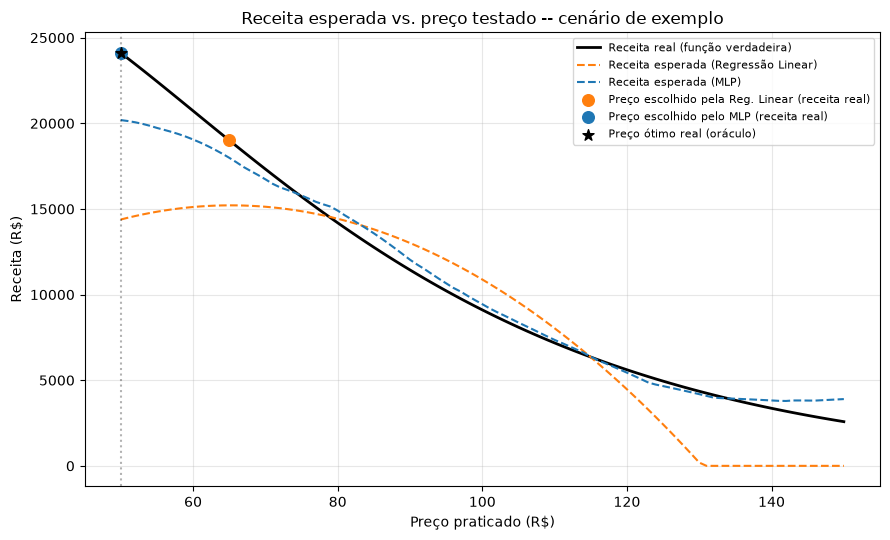

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(precos_candidatos, receita_real_oraculo, label="Receita real (função verdadeira)", color="black", linewidth=2)
ax.plot(precos_candidatos, receita_lr, label="Receita esperada (Regressão Linear)", color="tab:orange", linestyle="--")
ax.plot(precos_candidatos, receita_mlp, label="Receita esperada (MLP)", color="tab:blue", linestyle="--")

ax.axvline(preco_otimo_oraculo, color="black", alpha=0.3, linestyle=":")
ax.scatter([preco_escolhido_lr], [receita_real_com_preco_lr], color="tab:orange", zorder=5, s=70,
           label="Preço escolhido pela Reg. Linear (receita real)")
ax.scatter([preco_escolhido_mlp], [receita_real_com_preco_mlp], color="tab:blue", zorder=5, s=70,
           label="Preço escolhido pelo MLP (receita real)")
ax.scatter([preco_otimo_oraculo], [receita_otima_real], color="black", zorder=5, s=70, marker="*",
           label="Preço ótimo real (oráculo)")

ax.set_xlabel("Preço praticado (R$)")
ax.set_ylabel("Receita (R$)")
ax.set_title("Receita esperada vs. preço testado -- cenário de exemplo")
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Como interpretar MAE e RMSE aqui**

- **MAE** (erro absoluto médio): em média, quantas unidades de demanda o modelo erra para cima ou para baixo, sem considerar a direção do erro. É fácil de interpretar diretamente: um MAE de 54 unidades significa que, em média, o modelo erra a previsão de demanda em 54 unidades.
- **RMSE** (raiz do erro quadrático médio): também mede o erro em unidades de demanda, mas penaliza mais fortemente os erros grandes, pois eleva as diferenças ao quadrado antes de tirar a média. Quando o RMSE é bem maior que o MAE, é sinal de que o modelo comete alguns erros grandes ocasionais, além dos erros "típicos".

Em precificação, esses erros de previsão de demanda se propagam diretamente para a receita estimada (`receita = preço × demanda`) — um modelo que erra muito a demanda também erra a receita esperada de cada preço candidato, o que pode levar a escolher um preço abaixo ou acima do ideal.

**Veredito neste notebook**

Os números já registrados nas células acima mostram uma diferença grande entre os dois modelos:
- Regressão Linear: MAE = 54,265 | RMSE = 74,897
- MLP (rede neural): MAE = 11,761 | RMSE = 18,247

A rede neural teve um erro de previsão de demanda cerca de 4 a 5 vezes menor que a regressão linear, evidência de que ela captura melhor as não linearidades e interações da demanda simulada.

Esse ganho de precisão se reflete diretamente na decisão de preço: no cenário de exemplo, o MLP escolheu R$ 50 — exatamente o preço ótimo segundo a função verdadeira (oráculo) — enquanto a Regressão Linear escolheu R$ 65, um preço distante do ideal. Em receita real, isso significa R$ 24.108,41 para o MLP (igual ao ótimo) contra R$ 19.009,24 para a Regressão Linear: uma perda de aproximadamente R$ 5.099,17 (cerca de 21% de receita a menos) só por causa do erro de previsão do modelo baseline.

Neste notebook, portanto, a rede neural teve desempenho claramente superior tanto na métrica de erro de previsão quanto no resultado de negócio (receita).

**10. Conclusão**

Neste exemplo simulado, a demanda foi construída propositalmente com **interações não lineares** entre preço, estoque, proximidade do evento e dia da semana — exatamente o tipo de padrão que uma regressão linear tem dificuldade de representar sem engenharia manual de features, e que uma rede neural pode aprender diretamente dos dados brutos.

Observando as métricas de erro (MAE/RMSE) impressas nas células acima, é possível comparar objetivamente qual modelo generaliza melhor para o conjunto de teste. Na tabela e no gráfico da seção de precificação, comparamos o preço que cada abordagem recomendaria no cenário de exemplo e a **receita real** (segundo a função geradora verdadeira) que esse preço efetivamente traria, contra a receita do preço verdadeiramente ótimo.

Vale destacar as limitações desta demonstração:
- os dados são 100% simulados, com uma função geradora conhecida — em um caso real, nunca temos acesso ao "oráculo" para comparação, apenas a dados históricos;
- o tamanho da rede e a quantidade de dados foram propositalmente pequenos para permitir treino rápido em aula; em um cenário real de produção, mais dados, mais features de contexto (sazonalidade, marketing, clima etc.) e validação cuidadosa (ex.: validação cruzada, monitoramento de drift) seriam necessários antes de usar o modelo para decisões de preço automatizadas;
- a escolha do preço ótimo aqui foi feita por busca em grade (*grid search*) sobre um cenário fixo; em produção, isso seria repetido para cada combinação relevante de contexto, e frequentemente combinado com restrições de negócio (preço mínimo, teto de variação em relação ao concorrente, etc.).

**Validação com múltiplas seeds**

O walkthrough acima usa uma única seed (`42`) para gerar os dados, fazer o split treino/teste e inicializar os modelos. Isso deixa uma pergunta em aberto: a diferença observada entre Regressão Linear e MLP é um padrão robusto do problema simulado, ou um efeito de sorte associado a essa seed específica?

Para responder, repetimos o pipeline completo -- geração do dataset, split treino/teste e treino dos dois modelos -- para três seeds diferentes (`42`, `7`, `123`), mantendo a mesma função geradora de demanda (`demanda_verdadeira`) e a mesma arquitetura de MLP. Em cada seed, calculamos o MAE e o RMSE de cada modelo no respectivo conjunto de teste.

In [10]:
def rodar_pipeline_para_seed(seed):
    '''Repete o pipeline completo (geração de dados, split, treino de LinearRegression
    e MLPRegressor) para uma seed específica, usando um gerador de números aleatórios
    isolado (não interfere no np.random.seed(42) global usado no walkthrough acima).'''
    rng = np.random.RandomState(seed)

    dia_da_semana_s = rng.randint(0, 7, size=N)
    dias_ate_evento_s = rng.uniform(1, 60, size=N)
    estoque_restante_s = rng.uniform(0, 500, size=N)
    preco_concorrente_s = rng.uniform(60, 140, size=N)
    preco_praticado_s = rng.uniform(50, 150, size=N)

    demanda_media_s = demanda_verdadeira(
        dia_da_semana_s, dias_ate_evento_s, estoque_restante_s, preco_concorrente_s, preco_praticado_s
    )
    ruido_s = rng.normal(0, 5.0, size=N)
    demanda_s = np.clip(demanda_media_s + ruido_s, 0, None)

    df_s = pd.DataFrame({
        "dia_da_semana": dia_da_semana_s,
        "dias_ate_evento": dias_ate_evento_s,
        "estoque_restante": estoque_restante_s,
        "preco_concorrente": preco_concorrente_s,
        "preco_praticado": preco_praticado_s,
        "demanda": demanda_s,
    })

    X_s = df_s[features].values
    y_s = df_s[alvo].values
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_s, y_s, test_size=0.2, random_state=seed)

    modelo_lr_s = make_pipeline(StandardScaler(), LinearRegression())
    modelo_lr_s.fit(X_tr_s, y_tr_s)
    pred_lr_s = modelo_lr_s.predict(X_te_s)
    mae_lr_s = mean_absolute_error(y_te_s, pred_lr_s)
    rmse_lr_s = np.sqrt(mean_squared_error(y_te_s, pred_lr_s))

    modelo_mlp_s = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            max_iter=3000,
            early_stopping=True,
            random_state=seed,
        ),
    )
    modelo_mlp_s.fit(X_tr_s, y_tr_s)
    pred_mlp_s = modelo_mlp_s.predict(X_te_s)
    mae_mlp_s = mean_absolute_error(y_te_s, pred_mlp_s)
    rmse_mlp_s = np.sqrt(mean_squared_error(y_te_s, pred_mlp_s))

    return {
        "seed": seed,
        "MAE_LR": mae_lr_s,
        "RMSE_LR": rmse_lr_s,
        "MAE_MLP": mae_mlp_s,
        "RMSE_MLP": rmse_mlp_s,
    }


seeds_validacao = [42, 7, 123]
resultados_por_seed = [rodar_pipeline_para_seed(s) for s in seeds_validacao]
df_resultados_seeds = pd.DataFrame(resultados_por_seed)

# formato "long" (uma linha por seed x modelo) para facilitar agregação por modelo
df_resultados_long = pd.concat([
    pd.DataFrame({
        "seed": df_resultados_seeds["seed"],
        "Modelo": "Regressão Linear",
        "MAE": df_resultados_seeds["MAE_LR"],
        "RMSE": df_resultados_seeds["RMSE_LR"],
    }),
    pd.DataFrame({
        "seed": df_resultados_seeds["seed"],
        "Modelo": "MLP (rede neural)",
        "MAE": df_resultados_seeds["MAE_MLP"],
        "RMSE": df_resultados_seeds["RMSE_MLP"],
    }),
], ignore_index=True)

df_resultados_long

,seed,Modelo,MAE,RMSE
0,42,Regressão Linear,54.265,74.897
1,7,Regressão Linear,52.696,70.487
2,123,Regressão Linear,55.240,74.762
3,42,MLP (rede neural),11.761,18.247
4,7,MLP (rede neural),7.766,10.866
5,123,MLP (rede neural),10.078,16.126


In [11]:
resumo_seeds = df_resultados_long.groupby("Modelo").agg(
    MAE_media=("MAE", "mean"),
    MAE_desvio=("MAE", "std"),
    RMSE_media=("RMSE", "mean"),
    RMSE_desvio=("RMSE", "std"),
).reset_index()

resumo_seeds

,Modelo,MAE_media,MAE_desvio,RMSE_media,RMSE_desvio
0,MLP (rede neural),9.868,2.005,15.080,3.800
1,Regressão Linear,54.067,1.283,73.382,2.508


**A conclusão original se mantém?**

Sim. Nas três seeds testadas (`42`, `7`, `123`), a Regressão Linear obteve MAE entre 52,696 e 55,240 (média 54,067 ± 1,283) e RMSE entre 70,487 e 74,897 (média 73,382 ± 2,508). O MLP obteve MAE entre 7,766 e 11,761 (média 9,868 ± 2,005) e RMSE entre 10,866 e 18,247 (média 15,080 ± 3,800).

Ou seja, o MLP venceu a Regressão Linear com folga nas três seeds, sem exceção -- o erro do baseline foi de 4,6 a 6,8 vezes maior que o do MLP em MAE, a depender da seed (a razão original na seed 42, de ~4,6x, é o extremo inferior dessa faixa). Os desvios-padrão do MLP entre seeds (±2,0 em MAE) são maiores, proporcionalmente, do que os da Regressão Linear (±1,3), o que é esperado dado que a inicialização e o early stopping da rede neural têm mais variância de treino-para-treino do que uma regressão linear em forma fechada -- mas essa variância é pequena comparada à distância entre os dois modelos.

**Honestamente:** a conclusão do walkthrough original -- "a rede neural teve desempenho claramente superior tanto na métrica de erro de previsão quanto no resultado de negócio" -- não foi um artefato de sorte da seed 42. O padrão se repete de forma consistente nas três seeds, com folga suficiente (a pior seed do MLP em MAE, 11,761, ainda é menor que a melhor seed da Regressão Linear, 52,696) para que a comparação seja considerada robusta neste dataset simulado.

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui (rede neural prevendo demanda/conversão para otimizar preço) se aplica a diversos outros problemas de negócio:

### 1. Seguros
- **Precificação personalizada de apólices:** ajustar o preço do seguro com base no perfil de risco individual do cliente.

### 2. Hospitalidade
- **Precificação dinâmica de hospedagem:** ajustar preços de diárias com base em demanda, sazonalidade e concorrência (modelo usado por plataformas de aluguel de temporada).

### 3. Publicidade Digital
- **Lances em tempo real (ad bidding):** decidir automaticamente quanto pagar por um espaço de anúncio em leilões que acontecem em milissegundos.

### 4. Logística
- **Precificação dinâmica de frete:** ajustar tarifas de transporte com base em demanda, capacidade disponível e urgência da entrega.

**Exercício**

Tente por conta própria, a partir do código já escrito neste notebook:

1. **Demanda linear (sem os termos não lineares).** Crie uma versão simplificada de `demanda_verdadeira` em que `efeito_preco`, `efeito_estoque`, `efeito_proximidade` e `efeito_fds` sejam substituídos por termos **aditivos e lineares** nas variáveis originais (por exemplo, `demanda = base - a*preco_praticado + b*estoque_restante + c*dias_ate_evento + ...`, sem exponenciais, sem logística e sem multiplicação entre efeitos). Regenere o dataset com essa função e refaça o treino da Regressão Linear e do MLP. A vantagem do MLP sobre a Regressão Linear (em MAE/RMSE) diminui, desaparece ou se inverte? O que isso sugere sobre quando vale a pena usar uma rede neural em vez de um modelo linear em um problema real de precificação?

2. **Restrição de preço mínimo e máximo.** Escolha um cenário (pode ser o mesmo da Seção 8) e refaça a busca em grade de preços, mas agora restringindo `precos_candidatos` a uma faixa mais estreita que reflita uma política de negócio (por exemplo, o preço não pode ficar mais do que 15% abaixo nem 15% acima do `preco_concorrente_cenario`). Recalcule, dentro dessa faixa, o preço ótimo sugerido pela Regressão Linear, pelo MLP e pelo oráculo. O preço ótimo "irrestrito" de cada modelo estava dentro ou fora dessa faixa? A diferença de receita real entre os modelos aumenta, diminui ou fica igual quando a escolha é restringida?